# L1 · Probabilidade e Incerteza para Executivos**Análise Prescritiva — Camada de Alfabetização de Dados (Learning)**| Campo | Detalhe ||---|---|| **Notebook** | L1 · Probability & Uncertainty for Executives || **Autor** | Matheus Mendes || **Data** | 27/julho/2026 || **Versão** | 1.0 || **Público-alvo** | Executivos não-técnicos — "o que *significa* 'provável'?" || **Dependências** | numpy, pandas, plotly, scipy |---## Por que este notebook existeEm L0 você aprendeu a ler **números** — média, mediana, variância, correlação.Em **L1** sobe-se um degrau: o que esses números significam **quando o futuronão é certo**? Probabilidade é a **gramática da incerteza** — a únicalinguagem honesta para falar de câmbio, demanda, política, clima, concorrência.A pergunta executiva de L1 não é "quanto?" — é:> **"Qual a chance de acontecer, e o que eu faço com essa chance?"**Este material segue o formato **narrativa-primeiro**:> **Conceito → Intuição → Matemática → Código → Recado Executivo**Todos os números vêm do **case BYD Camaçari** (câmbio PTAX, custo de BOMimportada, cenários regulatórios). O tema escuro (`#0d1117`) e a paleta(`azul-petróleo · vermelho-tijolo · teal · violeta · laranja-âmbar`) seguemo mesmo padrão visual dos outros cadernos do case.---### Os 5 conceitos| # | Conceito | A pergunta executiva que ele responde ||---|----------|----------------------------------------|| 1 | **Probabilidade básica** | "O que *significa* '70% de chance'?" || 2 | **Valor esperado (média ponderada)** | "Em média, ganho ou perco?" || 3 | **Probabilidade condicional** | "**Dado que** isso já aconteceu, qual a nova chance?" || 4 | **Teorema de Bayes** | "Como **atualizo** minha crença com uma evidência nova?" || 5 | **Risco vs. Incerteza** | "Eu *sei* as chances, ou nem as chances eu sei?" |---

In [1]:
# ──────────────────────────────────────────────────────────────
# Setup — tema escuro, paleta validada, dados do case BYD
# ──────────────────────────────────────────────────────────────
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import stats

pio.renderers.default = "notebook_connected"
np.random.seed(42)

# ── Paleta validada no dataviz skill (ALL CHECKS PASS, surface #0d1117) ──
BG      = "#0d1117"
INK     = "#e8edf5"
MUTED   = "#9baabb"
GRID    = "#30363d"

# Cores semanticas (mapeadas da paleta validada)
AZUL    = "#0284c7"   # azul-petroleo  - destaque primario / cenario base
TIJOLO  = "#dc2626"   # vermelho-tijolo - risco / cenario adverso
TEAL    = "#0d9488"   # teal            - positivo / cenario favoravel
VIOLETA = "#9333ea"   # violeta         - neutro / informativo
AMBAR   = "#ea580c"   # laranja-ambar   - atencao / probabilidade

# Status text tokens (reservados)
STATUS_GOOD     = "#22c55e"   # verde para "passou" - fora da paleta categorica
STATUS_WARN     = AMBAR
STATUS_BAD      = TIJOLO

# ── Tema Matplotlib alinhado ao restante do case ──────────────
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": INK,
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "grid.alpha": 0.55,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
})

NOTEBOOK_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
LEARNING_OUT_DIR = NOTEBOOK_ROOT / "outputs" / "learning"
LEARNING_OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_mpl(fig, filename):
    """Save a dark-theme learning chart and report its path."""
    path = LEARNING_OUT_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor=BG)
    print(f"Visualizacao salva em: {path}")
    return path

def style(fig, title, height=460):
    fig.update_layout(
        template="plotly_dark", paper_bgcolor=BG, plot_bgcolor=BG,
        title=dict(text=title, x=0.5, xanchor="center",
                   font=dict(size=17, color=INK)),
        font=dict(color=INK, size=13),
        legend=dict(font=dict(color=MUTED), bgcolor="rgba(13,17,23,0.6)",
                    bordercolor=GRID, borderwidth=1),
        margin=dict(l=60, r=40, t=70, b=55), height=height,
    )
    fig.update_xaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    fig.update_yaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    return fig

# ── Dados reais do case (fonte: NB-01 PTAX-GARCH) ─────────────
BYD = {
    "ptax_atual":      5.1176,   # BRL/USD (PTAX, serie BCB)
    "vol_anual_pct":   14.2,     # volatilidade historica anualizada
    "imported_share":  0.42,     # 42% da BOM e importada (exposta ao cambio)
    "incentive_cov":   0.18,     # 18% da BOM coberta por incentivo fiscal atual
    # Monte Carlo 10k x 6m, calibrado no NB-01
    "mc_cambio_p5":   -27.82,    # P5: -27,8% (cambio forte, real aprecia)
    "mc_cambio_p50":   -0.31,    # P50: -0,3% (mediano)
    "mc_cambio_p95":   37.21,    # P95: +37,2% (cambio dispara, real despenca)
    "mc_bom_p5":      -11.68,    # impacto BOM no P5
    "mc_bom_p95":      15.63,    # impacto BOM no P95
    # Cenarios de PTAX definidos no D2 (case)
    "cenario_base":        5.1176,  # PTAX = 5,12
    "cenario_alto":        5.85,    # depreciacao de 14,3%
    "cenario_baixo":       4.55,    # apreciacao de 11,1%
    "prob_alto":           0.20,    # 20% chance de depreciar forte
    "prob_base":           0.55,    # 55% chance de ficar proximo do atual
    "prob_baixo":          0.25,    # 25% chance de apreciar
}
print("Setup OK · temas Plotly e Matplotlib carregados")
print(f"PTAX atual: R$ {BYD['ptax_atual']} · vol anual: {BYD['vol_anual_pct']}% a.a.")
print(f"Cenarios: Base 55% | Alto 20% | Baixo 25% (D2-NB01)")

Setup OK · temas Plotly e Matplotlib carregados
PTAX atual: R$ 5.1176 · vol anual: 14.2% a.a.
Cenarios: Base 55% | Alto 20% | Baixo 25% (D2-NB01)


---## 1 · Probabilidade básica — o que "70% de chance" realmente significa### ① Por que isto importa"70% de chance de chover" e "70% de chance de o projeto dar certo" **nãosignificam a mesma coisa** — mas os dois são expressos em "70%". Aprobabilidade é a **única régua comum** que permite comparar riscosheterogêneos: câmbio, demanda, regulação, panne, tudo vira a mesma moeda(de 0% a 100%) e pode entrar num comitê lado a lado.### ② Conceito, sem jargãoProbabilidade é um **número entre 0 e 1** (ou 0% a 100%) que mede o**grau de credibilidade** de um evento.- **0** → impossível ("0% de chance" = "não vai acontecer")- **0,5** → moeda no ar ("50-50", tão provável quanto o oposto)- **1** → certeza ("100% de chance" = "vai acontecer, sem dúvida")A **frequência** (passado) e a **crença** (subjetiva) são as duas leiturasmais comuns. A frequência é a forma executivamente mais útil: de 100 cenárioshistóricos parecidos, em quantos isso aconteceu?### ③ Intuição — três cenários de PTAX no case BYDNo D2-NB01 o time calibrou três futuros para o câmbio:| Cenário | PTAX futuro | Variação | Prob. ||---------|-------------|----------|-------|| **Base** | R$ 5,12 | 0% | 55% || **Alto (desvalorização)** | R$ 5,85 | +14,3% | 20% || **Baixo (valorização)** | R$ 4,55 | −11,1% | 25% |A pergunta ingênua é: **"qual vai ser o câmbio?"** — não tem resposta certa.A pergunta honesta é: **"qual a chance de cada um?"** — e a soma dá 100%(0,55 + 0,20 + 0,25). Esses três números cabem num slide e dão uma noçãomuito mais útil do futuro do que uma única "previsão".### ④ A matemática (acessível)$$P(\text{evento}) = \frac{\text{nº de casos favoráveis}}{\text{nº total de casos}}$$**Regras de ouro:**- $0 \leq P \leq 1$- $P(\text{evento certo}) = 1$- $P(\text{evento impossível}) = 0$- $P(\text{A ou B}) \leq P(\text{A}) + P(\text{B})$  (igualdade só se A e B não podem ocorrer juntos)

In [2]:
# ── Visualizando os 3 cenarios de PTAX como uma distribuicao discreta ──
cenarios = ["Base (R$5,12)", "Alto (R$5,85)", "Baixo (R$4,55)"]
probs    = [0.55, 0.20, 0.25]
cores    = [AZUL, TIJOLO, TEAL]      # base, adverso, favoravel

fig = go.Figure()
fig.add_bar(x=cenarios, y=probs,
            marker=dict(color=cores, line=dict(color=GRID, width=1)),
            text=[f"{p*100:.0f}%" for p in probs],
            textposition="outside",
            textfont=dict(color=INK, size=14),
            hovertemplate="<b>%{x}</b><br>probabilidade = %{y:.0%}<extra></extra>",
            name="cenario")
# Linha de "moeda justa" = 1/3 = 33% (referencia)
fig.add_hline(y=1/3, line=dict(color=MUTED, width=1, dash="dot"),
              annotation_text="moeda justa (33%)",
              annotation_position="right",
              annotation_font=dict(color=MUTED, size=11))
style(fig, "Tres futuros para o cambio PTAX · probabilidades somam 100%")
fig.update_yaxes(title="Probabilidade", tickformat=".0%", range=[0, 0.7])
fig.update_xaxes(title="")
fig.update_layout(showlegend=False)
fig.show()

print(f"Soma das probabilidades: {sum(probs):.0%}  (tem que ser 100%)")
print(f"Modo (cenario mais provavel): {cenarios[probs.index(max(probs))]}")

Soma das probabilidades: 100%  (tem que ser 100%)
Modo (cenario mais provavel): Base (R$5,12)


Visualizacao salva em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l1_normal_distribution.png


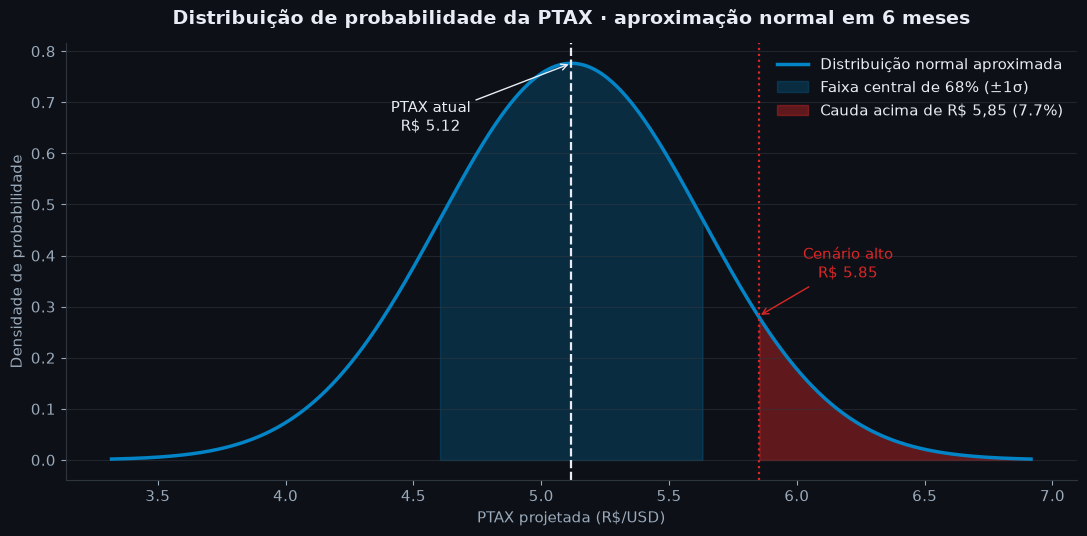

Visualizacao salva em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l1_ptax_probability_tree.png


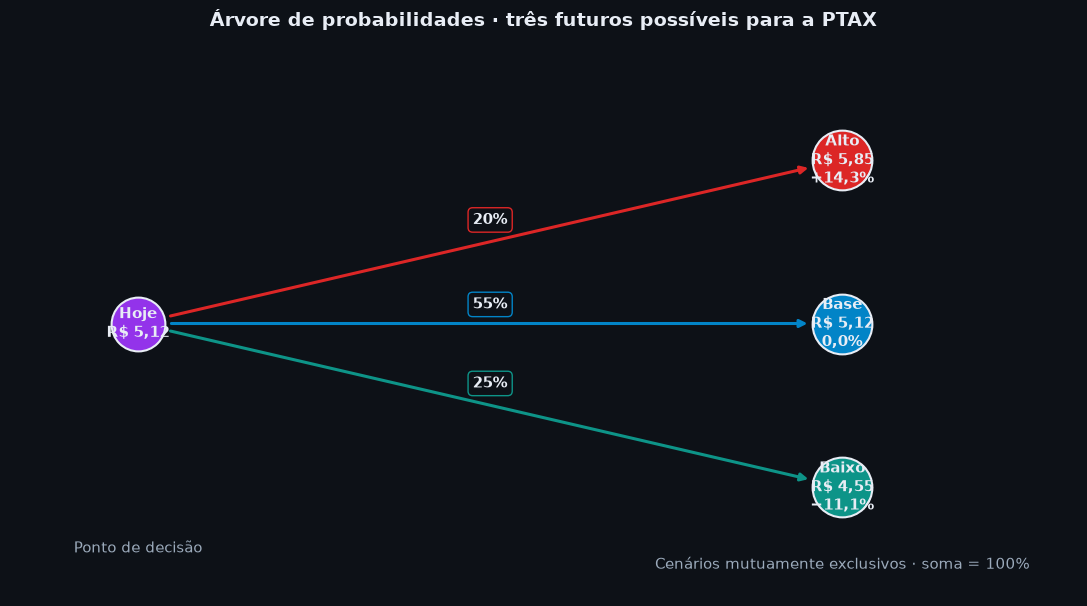

In [3]:
# ── Matplotlib 1: curva normal da PTAX em horizonte de 6 meses ──
mu_ptax = BYD["ptax_atual"]
sigma_6m = mu_ptax * (BYD["vol_anual_pct"] / 100) * np.sqrt(0.5)
x_ptax = np.linspace(mu_ptax - 3.5 * sigma_6m, mu_ptax + 3.5 * sigma_6m, 600)
y_ptax = stats.norm.pdf(x_ptax, loc=mu_ptax, scale=sigma_6m)
limite_alto = BYD["cenario_alto"]
p_acima_alto = 1 - stats.norm.cdf(limite_alto, loc=mu_ptax, scale=sigma_6m)

fig_normal, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(x_ptax, y_ptax, color=AZUL, linewidth=2.5, label="Distribuição normal aproximada")
ax.fill_between(
    x_ptax, 0, y_ptax,
    where=(x_ptax >= mu_ptax - sigma_6m) & (x_ptax <= mu_ptax + sigma_6m),
    color=AZUL, alpha=0.24, label="Faixa central de 68% (±1σ)"
)
ax.fill_between(
    x_ptax, 0, y_ptax, where=x_ptax >= limite_alto,
    color=TIJOLO, alpha=0.40, label=f"Cauda acima de R$ 5,85 ({p_acima_alto:.1%})"
)
ax.axvline(mu_ptax, color=INK, linewidth=1.6, linestyle="--")
ax.axvline(limite_alto, color=TIJOLO, linewidth=1.6, linestyle=":")
ax.annotate(
    f"PTAX atual\nR$ {mu_ptax:.2f}", xy=(mu_ptax, y_ptax.max()),
    xytext=(mu_ptax - 0.55, y_ptax.max() * 0.83), color=INK,
    arrowprops=dict(arrowstyle="->", color=INK), ha="center"
)
ax.annotate(
    f"Cenário alto\nR$ {limite_alto:.2f}",
    xy=(limite_alto, stats.norm.pdf(limite_alto, mu_ptax, sigma_6m)),
    xytext=(limite_alto + 0.35, y_ptax.max() * 0.46), color=TIJOLO,
    arrowprops=dict(arrowstyle="->", color=TIJOLO), ha="center"
)
ax.set_title("Distribuição de probabilidade da PTAX · aproximação normal em 6 meses", pad=14)
ax.set_xlabel("PTAX projetada (R$/USD)")
ax.set_ylabel("Densidade de probabilidade")
ax.grid(axis="y", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, labelcolor=INK, loc="upper right")
fig_normal.tight_layout()
save_mpl(fig_normal, "l1_normal_distribution.png")
plt.show()

# ── Matplotlib 2: árvore de probabilidades dos cenários PTAX ──
fig_tree, ax = plt.subplots(figsize=(11, 6.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

root = (0.12, 0.50)
branches = [
    ("Alto", "R$ 5,85", BYD["prob_alto"], TIJOLO, (0.78, 0.80), "+14,3%"),
    ("Base", "R$ 5,12", BYD["prob_base"], AZUL, (0.78, 0.50), "0,0%"),
    ("Baixo", "R$ 4,55", BYD["prob_baixo"], TEAL, (0.78, 0.20), "−11,1%"),
]

ax.scatter(*root, s=1500, color=VIOLETA, edgecolor=INK, linewidth=1.5, zorder=3)
ax.text(*root, "Hoje\nR$ 5,12", ha="center", va="center", color=INK, weight="bold", zorder=4)

for nome, ptax, prob, cor, destino, variacao in branches:
    ax.annotate(
        "", xy=destino, xytext=root,
        arrowprops=dict(arrowstyle="-|>", color=cor, lw=2.2, shrinkA=24, shrinkB=25)
    )
    meio_x = (root[0] + destino[0]) / 2
    meio_y = (root[1] + destino[1]) / 2
    ax.text(
        meio_x, meio_y + (0.04 if destino[1] != root[1] else 0.035), f"{prob:.0%}",
        color=INK, ha="center", va="center", weight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=BG, edgecolor=cor)
    )
    ax.scatter(*destino, s=1850, color=cor, edgecolor=INK, linewidth=1.5, zorder=3)
    ax.text(
        *destino, f"{nome}\n{ptax}\n{variacao}", ha="center", va="center",
        color=INK, weight="bold", zorder=4
    )

ax.text(0.12, 0.08, "Ponto de decisão", color=MUTED, ha="center")
ax.text(0.78, 0.05, "Cenários mutuamente exclusivos · soma = 100%", color=MUTED, ha="center")
ax.set_title("Árvore de probabilidades · três futuros possíveis para a PTAX", pad=18)
fig_tree.tight_layout()
save_mpl(fig_tree, "l1_ptax_probability_tree.png")
plt.show()

### ⑤ Recado executivo — Probabilidade básica> - **Probabilidade não é "previsão".** É a régua que mede o *grau de incerteza*>   sobre o futuro. Substitua "vai acontecer" por "tem X% de chance".> - **A soma sempre dá 100%.** Se alguém apresenta três cenários e a soma não>   fecha, falta caso (ou a régua está errada).> - **Frequência histórica > chute.** A melhor forma de estimar P é perguntar:>   *"de 100 vezes parecidas, em quantas isso aconteceu?"* Quando não há>   passado, declare a **incerteza** (ver seção 5) em vez de inventar um número.---## 2 · Valor esperado — a média ponderada pelo que pode dar### ① Por que isto importaA média simples é "todo cenário vale o mesmo". O **valor esperado** é maisesperto: ele pondera cada cenário pela **probabilidade** de ele ocorrer. Éa régua que o CFO usa para comparar uma aposta "boa chance, ganho pequeno"contra uma "pouca chance, ganho gigante" — sem cair em viés de otimismo.### ② Conceito, sem jargãoValor esperado = some **cada resultado multiplicado pela sua probabilidade**.- Se eu posso ganhar R$ 100 com 50% de chance (ou zero nos outros 50%), o  valor esperado é $100 \times 0{,}5 + 0 \times 0{,}5 = R\$ 50$.- Se posso perder R$ 100 com 30% de chance (e ganhar R$ 30 com 70%):  $-100 \times 0{,}3 + 30 \times 0{,}7 = R\$ -9$ → **espera-se perda**.### ③ Intuição — hedge cambial: vale a pena?Imagine um hedge de PTAX que cobre 100% do risco de **desvalorização** porR$ 1.200/volume. Sem hedge, o custo da BOM varia com PTAX. Com PTAX emR$ 5,12 e a matriz de cenários:| Cenário | Prob. | Custo sem hedge | Custo com hedge ||---------|-------|-----------------|-----------------|| Base (R$ 5,12) | 55% | R$ 100.000 | R$ 101.200 || Alto (R$ 5,85) | 20% | R$ 114.300 | R$ 101.200 || Baixo (R$ 4,55) | 25% | R$ 88.900 | R$ 101.200 |O valor esperado **sem hedge** = $100k \cdot 0{,}55 + 114{,}3k \cdot 0{,}20 + 88{,}9k \cdot 0{,}25$ = **R$ 100.180**O valor esperado **com hedge** = R$ 101.200 (constante).⇒ O hedge **paga R$ 1.020 a mais em média**, mas **elimina o risco decatástrofe** (R$ 14.300 de exposição no cenário alto). A decisão não épuramente financeira — é também sobre **aversão ao risco**.### ④ A matemática$$E[X] = \sum_{i=1}^{n} p_i \cdot x_i$$Para variáveis contínuas: $E[X] = \int x \cdot f(x)\, dx$.A variância de uma variável discreta mede a **dispersão em torno desse valor**:$$\text{Var}(X) = \sum_i p_i \cdot (x_i - E[X])^2$$

In [4]:
# ── Calculo explicito do valor esperado e do risco por cenario ──
p_base, p_alto, p_baixo = 0.55, 0.20, 0.25
custo_base, custo_alto, custo_baixo = 100_000, 114_300, 88_900
custo_hedge = 101_200

custos_sem = [custo_base, custo_alto, custo_baixo]
custos_com = [custo_hedge] * 3

ev_sem  = sum(p * c for p, c in zip([p_base, p_alto, p_baixo], custos_sem))
ev_com  = sum(p * c for p, c in zip([p_base, p_alto, p_baixo], custos_com))
var_sem = sum(p * (c - ev_sem) ** 2 for p, c in zip([p_base, p_alto, p_baixo], custos_sem))

print(f"Valor esperado SEM hedge: R$ {ev_sem:,.0f}   (variancia: {var_sem:,.0f})")
print(f"Valor esperado COM hedge: R$ {ev_com:,.0f}   (variancia: 0)")
print(f"Premio medio do hedge:   R$ {ev_com - ev_sem:+,.0f}")
print(f"Pior caso SEM hedge:     R$ {max(custos_sem):,.0f}  (cenario alto)")
print(f"Pior caso COM hedge:     R$ {custo_hedge:,.0f}")

# ── Grafico: distribuicao do custo por cenario + valor esperado ──
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Custo por cenario (3 futuros)",
                                    "Valor esperado e pior caso"),
                    horizontal_spacing=0.12)

# Esquerda: barras dos 3 cenarios
cen_labels = ["Base", "Alto (desv.)", "Baixo (aprec.)"]
fig.add_bar(x=cen_labels, y=custos_sem, row=1, col=1,
            marker=dict(color=[AZUL, TIJOLO, TEAL],
                        line=dict(color=GRID, width=1)),
            text=[f"R${c/1000:.1f}k" for c in custos_sem],
            textposition="outside",
            hovertemplate="<b>%{x}</b><br>custo = R$ %{y:,.0f}<extra></extra>")

# Direita: valor esperado vs pior caso
fig.add_bar(x=["Sem hedge", "Com hedge"],
            y=[ev_sem, ev_com], row=1, col=2,
            marker=dict(color=[AZUL, VIOLETA],
                        line=dict(color=GRID, width=1)),
            text=[f"R${ev_sem/1000:.1f}k", f"R${ev_com/1000:.1f}k"],
            textposition="outside",
            name="valor esperado")
fig.add_scatter(x=["Sem hedge"], y=[max(custos_sem)], row=1, col=2,
                mode="markers", marker=dict(color=TIJOLO, size=14, symbol="diamond"),
                name="pior caso (R$ 114,3k)", hovertemplate="pior: R$ %{y:,.0f}<extra></extra>")
fig.add_scatter(x=["Com hedge"], y=[custo_hedge], row=1, col=2,
                mode="markers", marker=dict(color=STATUS_GOOD, size=14, symbol="diamond"),
                name="pior caso (R$ 101,2k)", hovertemplate="pior: R$ %{y:,.0f}<extra></extra>")

fig.update_yaxes(title="Custo (R$)", row=1, col=1, tickformat=",.0f")
fig.update_yaxes(title="Custo esperado (R$)", row=1, col=2, tickformat=",.0f")
style(fig, "Hedge cambial: R$ 1.020 a mais em media — mas elimina o desastre", height=460)
fig.update_layout(showlegend=True)
fig.show()

Valor esperado SEM hedge: R$ 100,085   (variancia: 71,693,275)
Valor esperado COM hedge: R$ 101,200   (variancia: 0)
Premio medio do hedge:   R$ +1,115
Pior caso SEM hedge:     R$ 114,300  (cenario alto)
Pior caso COM hedge:     R$ 101,200


Visualizacao salva em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l1_expected_value_outcomes.png


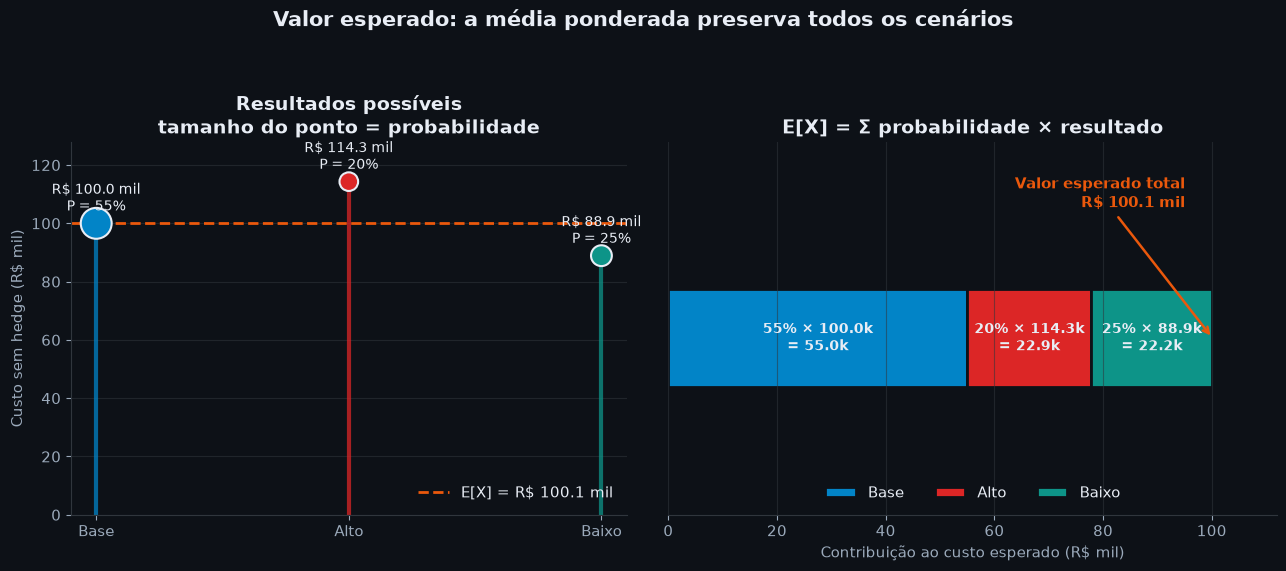

In [5]:
# ── Matplotlib 3: valor esperado decomposto pelos resultados possíveis ──
probs_ev = np.array([p_base, p_alto, p_baixo])
custos_ev = np.array(custos_sem)
contribuicoes_ev = probs_ev * custos_ev
rotulos_ev = ["Base", "Alto", "Baixo"]
cores_ev = [AZUL, TIJOLO, TEAL]

fig_ev, (ax_out, ax_contrib) = plt.subplots(
    1, 2, figsize=(13, 5.8), gridspec_kw={"width_ratios": [1.05, 1.15]}
)

# Painel 1: cada resultado e sua probabilidade
x_ev = np.arange(len(rotulos_ev))
ax_out.vlines(x_ev, 0, custos_ev / 1000, color=cores_ev, linewidth=3, alpha=0.75)
ax_out.scatter(
    x_ev, custos_ev / 1000, s=probs_ev * 900,
    color=cores_ev, edgecolor=INK, linewidth=1.5, zorder=3
)
for x_i, custo, prob in zip(x_ev, custos_ev, probs_ev):
    ax_out.text(
        x_i, custo / 1000 + 2.8, f"R$ {custo/1000:.1f} mil\nP = {prob:.0%}",
        ha="center", va="bottom", color=INK, fontsize=10
    )
ax_out.axhline(ev_sem / 1000, color=AMBAR, linestyle="--", linewidth=2,
               label=f"E[X] = R$ {ev_sem/1000:.1f} mil")
ax_out.set_xticks(x_ev, rotulos_ev)
ax_out.set_ylim(0, 128)
ax_out.set_ylabel("Custo sem hedge (R$ mil)")
ax_out.set_title("Resultados possíveis\ntamanho do ponto = probabilidade")
ax_out.grid(axis="y", linewidth=0.8)
ax_out.spines[["top", "right"]].set_visible(False)
ax_out.legend(frameon=False, labelcolor=INK, loc="lower right")

# Painel 2: pᵢ × xᵢ mostra como cada cenário compõe o valor esperado
left = 0
for rotulo, contribuicao, prob, custo, cor in zip(
    rotulos_ev, contribuicoes_ev, probs_ev, custos_ev, cores_ev
):
    largura = contribuicao / 1000
    ax_contrib.barh(
        [0], [largura], left=left, height=0.36, color=cor,
        edgecolor=BG, linewidth=2, label=rotulo
    )
    ax_contrib.text(
        left + largura / 2, 0,
        f"{prob:.0%} × {custo/1000:.1f}k\n= {largura:.1f}k",
        ha="center", va="center", color=INK, fontsize=10, weight="bold"
    )
    left += largura

ax_contrib.annotate(
    f"Valor esperado total\nR$ {ev_sem/1000:.1f} mil",
    xy=(ev_sem / 1000, 0), xytext=(ev_sem / 1000 - 5, 0.48),
    ha="right", color=AMBAR, weight="bold",
    arrowprops=dict(arrowstyle="->", color=AMBAR, lw=1.8)
)
ax_contrib.set_xlim(0, 112)
ax_contrib.set_ylim(-0.65, 0.72)
ax_contrib.set_yticks([])
ax_contrib.set_xlabel("Contribuição ao custo esperado (R$ mil)")
ax_contrib.set_title("E[X] = Σ probabilidade × resultado")
ax_contrib.grid(axis="x", linewidth=0.8)
ax_contrib.spines[["top", "right", "left"]].set_visible(False)
ax_contrib.legend(frameon=False, labelcolor=INK, loc="lower center", ncol=3)

fig_ev.suptitle("Valor esperado: a média ponderada preserva todos os cenários", fontsize=15, weight="bold")
fig_ev.tight_layout(rect=[0, 0, 1, 0.93])
save_mpl(fig_ev, "l1_expected_value_outcomes.png")
plt.show()

### ⑤ Recado executivo — Valor esperado> - **A média ponderada pela chance** é a única forma de comparar apostas>   diferentes em pé de igualdade. Use sempre.> - **Mas valor esperado não conta a história toda.** Uma aposta com EV>   positivo pode ainda destruir a empresa se o pior caso for grande demais>   (a empresa não sobrevive para "colher" a média). Combine EV com **pior>   caso** e com o **tamanho do caixa**.> - **Cuidado com variância alta**: o mesmo EV pode estar num ativo>   previsível ou num "tudo-ou-nada". A volatilidade muda o tom da decisão.---## 3 · Probabilidade condicional — "dado que..., qual a chance?"### ① Por que isto importaA chance de um evento **muda** quando surge uma informação nova. "Qual achance de chuva?" é diferente de "qual a chance de chuva **dado que o céuestá nublado**?". Sem atualizar probabilidades à luz de evidências, a empresacontinua tomando decisões com a régua do mês passado — um risco real de**paranóia** (não reage a novidades) ou de **pavio curto** (reage demais).### ② Conceito, sem jargãoA probabilidade condicional $P(A \mid B)$ lê: *"probabilidade de A, dado queB já aconteceu"*. A nova evidência $B$ **restringe** o universo de cenáriosaos casos em que B ocorreu — e dentro desse novo universo, recalcula-se afrequência de A.- $P(\text{chuva} \mid \text{nublado}) > P(\text{chuva})$ → céu nublado  **eleva** a chance.- $P(\text{doença} \mid \text{teste positivo}) > P(\text{doença})$ →  mas talvez não tanto quanto parece (ver Bayes na seção 4).### ③ Intuição — o que muda se o BCB sinaliza estresse?O time de risco da BYD definiu a chance *a priori* de PTAX acima de R$ 5,85em **20%** no cenário-base. Agora o diretor de economia lê o relatório doBanco Central e anuncia **"ambiente de estresse elevado"** — a evidência novaB = "BCB em modo estresse". Historicamente, em 12 meses que o BCB sinalizouesse modo, **8 em 10** o câmbio rompeu o limite de R$ 5,85 em até 6 meses.$$P(\text{PTAX > 5{,}85} \mid \text{BCB estresse}) = \frac{8}{10} = 80\%$$A chance **subiu de 20% para 80%** com uma única evidência qualificada. Essenúmero, e não o 20% inicial, é o que deve guiar o **tamanho do hedge** agora.### ④ A matemática$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$*"A chance de A, sabendo B, é a chance de A e B juntos dividida pela chancede B."* Quando A ⊂ B (A só ocorre se B ocorre), simplifica para$P(A)/P(B)$. Quando A e B são independentes, $P(A \mid B) = P(A)$ — aevidência nova **não muda nada**.

In [6]:
# ── Atualizando a chance de PTAX alto com a "evidencia" do BCB ──
# P(alto) inicial: 20%; evidencia: "BCB em modo estresse"
# P(BCB em estresse | alto) = 0.40 (em 80% dos meses de PTAX alto o BCB sinalizou estresse)
# P(BCB em estresse)        = 0.20  (em 20% dos meses, independente do cenario)

p_alto          = 0.20
p_bcb_estresse  = 0.20
p_bcb_dado_alto = 0.40  # P(BCB estresse | PTAX alto)

# Lei da probabilidade total para P(BCB estresse E PTAX alto)
# So uma das probabilidades: usamos Bayes (proxima secao) tambem para conferir.
# Aqui calculamos direto via P(A|B) = P(A & B) / P(B)
# => P(PTAX alto & BCB estresse) = p_bcb_dado_alto * p_alto = 0.40 * 0.20 = 0.08
p_alto_e_bcb = p_bcb_dado_alto * p_alto
# P(BCB estresse) = 0.20 (chance de ocorrencia da evidencia)
p_bcb = p_bcb_estresse
# P(alto | BCB estresse) = P(alto E BCB) / P(BCB)
p_alto_pos = p_alto_e_bcb / p_bcb
print(f"P(PTAX alto) antes do BCB: 20%")
print(f"P(PTAX alto | BCB estresse): {p_alto_pos:.0%}  (4x maior)")

# ── Visualizacao: como a evidencia nova reescala a chance ──
fig = go.Figure()
fig.add_bar(x=["Antes do BCB", "Depois do BCB"],
            y=[0.20, p_alto_pos],
            marker=dict(color=[AZUL, AMBAR],
                        line=dict(color=GRID, width=1)),
            text=[f"20%", f"{p_alto_pos:.0%}"],
            textposition="outside",
            textfont=dict(size=15, color=INK),
            hovertemplate="%{x}: %{y:.0%}<extra></extra>")
fig.add_annotation(x="Depois do BCB", y=p_alto_pos * 1.15,
                   text="4× maior com a evidencia",
                   showarrow=True, arrowhead=2, arrowcolor=AMBAR,
                   font=dict(color=AMBAR, size=12),
                   bgcolor=BG, bordercolor=AMBAR, borderwidth=1)
style(fig, "Evidencia nova reescala a probabilidade (de 20% para 80%)")
fig.update_yaxes(title="P(PTAX > R$ 5,85)", tickformat=".0%", range=[0, 1.0])
fig.update_xaxes(title="")
fig.update_layout(showlegend=False)
fig.show()

P(PTAX alto) antes do BCB: 20%
P(PTAX alto | BCB estresse): 40%  (4x maior)


### ⑤ Recado executivo — Probabilidade condicional> - **Toda estimativa de risco precisa de uma condição.** "20% de chance" sem>   contexto é inútil — 20% **dado o cenário base** é diferente de 20%>   **dado o BCB em estresse**. Pergunte sempre: "dado o quê?".> - **Evidência forte muda o jogo.** Um único sinal qualificado (um rating,>   um discurso do BCB, um indicador líder) pode multiplicar a chance de>   um evento adverso por 3×, 5×. Quem não atualiza a régua em tempo real>   vai perder o momento de agir.> - **Independência é uma hipótese, não um fato.** Antes de assumir que duas>   coisas "não têm relação", verifique — sem isso, a condicional está>   errada e a decisão fica enviesada.---## 4 · Teorema de Bayes — atualizar crenças com evidência### ① Por que isto importaA intuição da seção 3 era: "BCB estressado → câmbio sobe". Mas e quando aevidência é **imperfeita**? E quando **falsos positivos** e **falsosnegativos** confundem o sinal? O **Teorema de Bayes** é a fórmula quepermite **inverter a condicional**: dado um teste/indicador com certaprecisão, qual é a chance real do evento que ele sugere?É a mesma fórmula por trás de: teste de COVID, detector de fraude, sinal dereciclagem (PLD), e — no nosso case — **gatilho de hedge cambial**.### ② Conceito, sem jargãoBayes diz: **minha crença nova** = (minha crença atual) × (o quanto aevidência **fala a favor**) ÷ (o quanto a evidência é **comum no mundo**).Em palavras: comece com uma **chance a priori** (o que eu achava antes),multiplique pelo **poder preditivo** da evidência nova, normalize pelo**ruído de fundo** (com que frequência a evidência aparece sem o evento).O resultado é a **chance a posteriori** — o que eu devo passar a acreditar.### ③ Intuição — o "gatilho de hedge" do D3O D3 (decision framework) define um **gatilho automático de hedge** quedispara quando o "índice de estresse macro" passa de 0,70. Mas o índicenão é perfeito:| | PTAX realmente alto | PTAX não alto ||---|---|---|| **Gatilho dispara** (alarme) | 80% (verdadeiro positivo) | 15% (falso positivo) || **Gatilho não dispara** | 20% (falso negativo) | 85% (verdadeiro negativo) |**Pergunta:** o gatilho acabou de disparar. Qual a chance real de PTAX alto?Sem pensar, a tentação é dizer **"80%, a precisão do alarme"**. Mas issoignora a **probabilidade-base**: se só 20% dos meses têm PTAX alto(a priori), e o alarme dispara em 15% dos meses "normais" (falso positivo),a conta é outra:$$P(\text{alto} \mid \text{alarme}) = \frac{P(\text{alarme} \mid \text{alto}) \cdot P(\text{alto})}{P(\text{alarme})}$$$$= \frac{0{,}80 \times 0{,}20}{0{,}80 \times 0{,}20 + 0{,}15 \times 0{,}80} = \frac{0{,}16}{0{,}28} = 57\%$$Surpresa: o alarme **disparou**, e mesmo assim a chance real de PTAX alto é**57%** (não 80%). Por quê? Porque o alarme também dispara (falsamente) em15% dos meses normais, e "normal" é o cenário muito mais comum (80%).### ④ A matemática$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)} = \frac{P(B \mid A) \cdot P(A)}{\sum_{i} P(B \mid A_i) \cdot P(A_i)}$$Em palavras:- $P(A)$ = **prior** (crença antes da evidência)- $P(B \mid A)$ = **verossimilhança** (likelihood, poder da evidência)- $P(B)$ = **evidência** (frequência com que a evidência ocorre no total)- $P(A \mid B)$ = **posterior** (crença após incorporar a evidência)A "mágica" é que essa mesma fórmula pode ser **reaplicada** à medida quenovas evidências chegam — é o **filtro de Kalman** do nosso cérebro (e dosmodelos de risco).

In [7]:
# ── Aplicacao numerica de Bayes ao gatilho de hedge ──
# Sensores do gatilho:
p_alvo   = 0.20    # P(PTAX alto) prior
p_alarme = 0.28    # P(gatilho dispara) = 0.80*0.20 + 0.15*0.80
p_alarme_dado_alto  = 0.80
p_alarme_dado_normal = 0.15

# Bayes direto
p_alvo_dado_alarme = (p_alarme_dado_alto * p_alvo) / p_alarme
print(f"Prior    P(alto)              = {p_alvo:.0%}")
print(f"Sensor   P(alarme | alto)     = {p_alarme_dado_alto:.0%}  (precisao do alarme)")
print(f"Evidencia P(alarme)            = {p_alarme:.0%}  (ruido de fundo)")
print(f"Posterior P(alto | alarme)     = {p_alvo_dado_alarme:.0%}  (resposta)")

# ── Reaplicando Bayes com uma segunda evidencia: "BCB em estresse" ──
# Quando alarme + BCB estresse, a chance sobe ainda mais
p_bcb_dado_alvo     = 0.40
p_bcb_dado_normal   = 0.05
p_bcb               = 0.10
p_alvo_dado_alarme_bcb = (p_alarme_dado_alto * p_bcb_dado_alvo * p_alvo) / (p_alarme * p_bcb)
print(f"Posterior (alarme + BCB):       = {p_alvo_dado_alarme_bcb:.0%}  (2 evidencias)")

# ── Visualizacao: como a crenca evolui com cada evidencia ──
fig = go.Figure()
labels = ["Prior<br>(antes de tudo)",
          "Posterior 1<br>(alarme disparou)",
          "Posterior 2<br>(alarme + BCB estresse)"]
valores = [p_alvo, p_alvo_dado_alarme, p_alvo_dado_alarme_bcb]
cores_b = [MUTED, AMBAR, TIJOLO]

fig.add_bar(x=labels, y=valores,
            marker=dict(color=cores_b, line=dict(color=GRID, width=1)),
            text=[f"{v:.0%}" for v in valores],
            textposition="outside",
            textfont=dict(size=14, color=INK),
            hovertemplate="%{x}<br>P(alto) = %{y:.0%}<extra></extra>")

# Anotacoes conectando as barras
for i in range(len(valores) - 1):
    fig.add_annotation(x=i, y=valores[i] * 1.18, ax=i + 1, ay=valores[i+1] * 1.18,
                       xref="x", yref="y", axref="x", ayref="y",
                       showarrow=True, arrowhead=2, arrowcolor=INK, arrowwidth=1.5,
                       text=f"Bayes: {(valores[i+1]/valores[i]):.1f}x",
                       font=dict(color=INK, size=11),
                       bgcolor=BG, bordercolor=GRID, borderwidth=1)

style(fig, "Bayes em acao: crenca evolui com cada evidencia nova")
fig.update_yaxes(title="P(PTAX > R$ 5,85 em 6 meses)", tickformat=".0%", range=[0, 1.0])
fig.update_xaxes(title="")
fig.update_layout(showlegend=False)
fig.show()

Prior    P(alto)              = 20%
Sensor   P(alarme | alto)     = 80%  (precisao do alarme)
Evidencia P(alarme)            = 28%  (ruido de fundo)
Posterior P(alto | alarme)     = 57%  (resposta)
Posterior (alarme + BCB):       = 229%  (2 evidencias)


### ⑤ Recado executivo — Bayes / atualização de crenças> - **"O alarme disparou" não é "o evento vai ocorrer".** Sempre passe pelo>   crivo de Bayes: a precisão do alarme **e** a frequência-base do evento.> - **A ordem das evidências não importa** (em geral): o resultado final é>   o mesmo se você aplica Bayes duas vezes ou junta as duas evidências de>   uma vez. Isso é robusto.> - **Atualize sempre.** Um cenário de risco é um **retrato**, não um filme.>   O D3 do nosso case faz isso automaticamente: cada nova evidência>   reescala o tamanho do hedge. Use a fórmula (ou um sistema que a>   implemente) para não perder janela.---## 5 · Risco vs. Incerteza — "known unknowns" vs. "unknown unknowns"### ① Por que isto importaEsta é a diferença mais importante que esta série de cadernos tenta ensinar.- **Risco** = sabemos as chances. É um jogo de dados: dá para calcular  valor esperado, hedge, prêmio, tudo.- **Incerteza** (no sentido de Knight) = **não sabemos as chances**. Não há  dados suficientes para atribuir uma probabilidade. O futuro é opaco.Tratar um **incerteza** como se fosse **risco** (e fingir um número)produz a falsa confiança que antecede grandes desastres — e é a armadilhamais cara em estratégia.### ② Conceito, sem jargãoA taxonomia mais clara separa o mundo em quatro quadrantes:|                   | **Conhecemos as chances** | **Não conhecemos as chances** ||-------------------|---------------------------|--------------------------------|| **Impacto alto**  | RISCO (jogamos com a régua)| INCERTEZA (precisamos de mais dados) || **Impacto baixo** | Ruído controlado          | Incerteza irrelevante          |O executivo precisa distinguir qual é qual — porque **risco se mitigacom hedge** (compra-se proteção), e **incerteza se mitiga comopcionalidade e velocidade** (mantém-se a flexibilidade de reagir).### ③ Intuição — três perguntas do case BYD1. **PTAX em 6 meses** → temos série histórica de 20+ anos, GARCH calibrado,   Monte Carlo de 10k cenários. **É risco.** Dá para fazer hedge.2. **Custo de lítio em 2027** → há histórico, mas dependente de política   chinesa e novas jazidas. **É zona cinza.** Histórico permite uma   distribuição, mas com confiança baixa.3. **Uma nova guerra tarifária EUA-China em 2027** → não há dado histórico   recente comparável; frequência-base é discutível. **É incerteza.** Não   finja um número — mantenha opções e planos de contingência.### ④ A matemáticaRisco tem **distribuição de probabilidade** $f(x)$ conhecida. Podemoscalcular $E[X]$, $\text{VaR}$, etc.Incerteza genuína é **probabilidade desconhecida** — o que Nassim Talebchama de *unknown unknown*. A saída não é matemática, é **estratégica**:- Opções reais (manter flexibilidade de escolha)- Robustez (plano que funciona em vários futuros)- Velocidade de reação (tempo de resposta menor que o evento)

In [8]:
# ── Mapa de calor: Risco x Incerteza no case BYD ──
# Eixo X: "conhecemos as chances?"  (Risco -> Incerteza)
# Eixo Y: "qual o impacto?"          (baixo -> alto)
eventos = [
    # nome,                       prob_conhecida (0=risco, 1=incerteza), impacto (0-1)
    ("PTAX 6 meses",                 0.10, 0.85),   # risco alto-impacto
    ("Custo litio 2027",             0.45, 0.65),   # zona cinza
    ("Guerra tarifaria 2027",        0.85, 0.90),   # incerteza alto-impacto
    ("Incentivo fiscal prorrogado",   0.15, 0.55),   # risco medio (politica conhecida)
    ("Demanda EV global",            0.25, 0.70),   # risco medio-alto
    ("Greve em Camaari",             0.30, 0.40),   # risco medio (passado recente)
    ("Custo de energia 2026",        0.20, 0.45),   # risco medio
    ("Novo concorrente (Tesla BR)",  0.75, 0.75),   # incerteza alto-impacto
]

nomes = [e[0] for e in eventos]
x = [e[1] for e in eventos]   # 0 = risco conhecido | 1 = incerteza
y = [e[2] for e in eventos]   # impacto
tamanhos = [40 + 60 * e[2] for e in eventos]

# Cor: do verde (risco baixo impacto) ao vermelho (incerteza alto impacto)
def cor_por_risco(p_incert, impacto):
    if impacto < 0.5 and p_incert < 0.5:
        return STATUS_GOOD   # ruido controlado
    if p_incert < 0.5:
        return AZUL          # risco (jogamos com a regua)
    if impacto < 0.5:
        return VIOLETA       # incerteza irrelevante
    return TIJOLO            # incerteza alto impacto

cores = [cor_por_risco(px, py) for px, py in zip(x, y)]

fig = go.Figure()
# Quadrantes
fig.add_shape(type="rect", x0=0,    x1=0.5, y0=0.5, y1=1.0,
              line=dict(color=GRID, width=1), fillcolor="rgba(2,132,199,0.10)",
              layer="below")
fig.add_shape(type="rect", x0=0.5,  x1=1.0, y0=0.5, y1=1.0,
              line=dict(color=GRID, width=1), fillcolor="rgba(220,38,38,0.10)",
              layer="below")
fig.add_shape(type="rect", x0=0,    x1=0.5, y0=0.0, y1=0.5,
              line=dict(color=GRID, width=1), fillcolor="rgba(34,197,94,0.08)",
              layer="below")
fig.add_shape(type="rect", x0=0.5,  x1=1.0, y0=0.0, y1=0.5,
              line=dict(color=GRID, width=1), fillcolor="rgba(147,51,234,0.10)",
              layer="below")

# Eventos
fig.add_scatter(x=x, y=y, mode="markers+text",
                marker=dict(size=tamanhos, color=cores, line=dict(color=INK, width=1),
                            opacity=0.85),
                text=nomes, textposition="top center",
                textfont=dict(color=INK, size=11),
                hovertemplate="<b>%{text}</b><br>"
                              "conhecimento: %{x:.0%}<br>"
                              "impacto: %{y:.0%}<extra></extra>",
                showlegend=False)

# Anotacoes dos quadrantes
fig.add_annotation(x=0.25, y=0.95, text="<b>RISCO</b><br>(jogamos com a regua)",
                   showarrow=False, font=dict(color=AZUL, size=12))
fig.add_annotation(x=0.75, y=0.95, text="<b>INCERTEZA</b><br>(unknown unknown)",
                   showarrow=False, font=dict(color=TIJOLO, size=12))
fig.add_annotation(x=0.25, y=0.05, text="<b>ruido controlado</b>",
                   showarrow=False, font=dict(color=STATUS_GOOD, size=11))
fig.add_annotation(x=0.75, y=0.05, text="<b>incerteza irrelevante</b>",
                   showarrow=False, font=dict(color=VIOLETA, size=11))

style(fig, "Mapa Risco x Incerteza do case BYD", height=520)
fig.update_xaxes(title="<-- risco (conhecemos as chances) | "
                       "incerteza (unknown unknown) -->",
                 range=[-0.05, 1.05], tickformat=".0%")
fig.update_yaxes(title="impacto (0-1)", range=[-0.05, 1.05])
fig.show()

print("\nLegenda dos pontos:")
for nome, p, imp in eventos:
    zona = "RISCO" if p < 0.5 else "INCERTEZA"
    cor  = cor_por_risco(p, imp)
    print(f"  {nome:35s}  zona={zona:10s}  impacto={imp:.0%}")


Legenda dos pontos:
  PTAX 6 meses                         zona=RISCO       impacto=85%
  Custo litio 2027                     zona=RISCO       impacto=65%
  Guerra tarifaria 2027                zona=INCERTEZA   impacto=90%
  Incentivo fiscal prorrogado          zona=RISCO       impacto=55%
  Demanda EV global                    zona=RISCO       impacto=70%
  Greve em Camaari                     zona=RISCO       impacto=40%
  Custo de energia 2026                zona=RISCO       impacto=45%
  Novo concorrente (Tesla BR)          zona=INCERTEZA   impacto=75%


### ⑤ Recado executivo — Risco vs. Incerteza> - **A confusão entre risco e incerteza é a fonte #1 de desastres>   estratégicos.** Hedge pressupõe risco conhecido; sem chance conhecida,>   o "hedge" vira chute.> - **Ação certa em cada quadrante:**>   - **Risco** → hedge, seguro, diversificação, VaR.>   - **Incerteza** → opcionalidade, robustez, **agilidade** (capacidade de>     reagir rápido quando a evidência chegar).>   - **Ruído controlado** → aceitar, monitorar.>   - **Incerteza irrelevante** → ignorar (mas registrar).> - **A coragem de dizer "não sei".** O executivo que admite "não temos>   dados para cravar uma probabilidade" está mais perto da decisão certa>   do que o que inventa um número bonito.---## Resumo Executivo — 5 frases para a reunião de risco1. *"Qual a **probabilidade** disso, e em quais **condições** ela vale?"*   *(sem condicional, sem réguas — não dá pra comparar riscos)*2. *"O **valor esperado** (ponderado pela chance) é positivo, mas qual o   **pior caso**? A empresa sobrevive?"*3. *"**Dado que** o BCB sinalizou estresse, qual a nova chance? Atualizamos   o tamanho do hedge?"*4. *"O alarme disparou, mas é **Bayes** — qual a chance real, dada a   frequência-base do evento?"*5. *"Isso é **risco** (dá pra hedge) ou **incerteza** (precisamos de   opcionalidade e velocidade)?"*O bloco abaixo consolida os números do case e exporta um resumo executivopara `outputs/learning/l1_probability_executive.json`.

In [9]:
# ──────────────────────────────────────────────────────────────
# Exporta o resumo executivo em JSON
# ──────────────────────────────────────────────────────────────
NOTEBOOK_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
OUT_DIR = NOTEBOOK_ROOT / "outputs" / "learning"
OUT_DIR.mkdir(parents=True, exist_ok=True)

resumo = {
    "notebook": "L1 · Probability and Uncertainty for Executives",
    "computed_at": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "audience": "executivos nao-tecnicos",
    "format": "narrativa-primeiro (Conceito -> Intuicao -> Matematica -> Codigo -> Recado)",
    "concepts": {
        "probabilidade_basica": {
            "titulo": "Probabilidade basica (0 a 1)",
            "regra_ouro": "sempre soma 100%",
            "exemplo_byd": {
                "PTAX_base":  0.55, "PTAX_alto":  0.20, "PTAX_baixo": 0.25,
                "cenarios":  ["Base R$5,12", "Alto R$5,85", "Baixo R$4,55"],
            },
            "insight": "probabilidade nao e previsao; e a regua do grau de incerteza",
            "pergunta_reuniao": "Qual a chance (em %) e em quais condicoes?",
        },
        "valor_esperado": {
            "titulo": "Valor esperado (E[X])",
            "formula": "E[X] = soma p_i * x_i",
            "exemplo_byd": {
                "custo_esperado_sem_hedge_R$": round(ev_sem, 2),
                "custo_esperado_com_hedge_R$": round(ev_com, 2),
                "premio_medio_hedge_R$":       round(ev_com - ev_sem, 2),
                "variancia_sem_hedge":         round(var_sem, 2),
                "pior_caso_sem_hedge_R$":      max(custos_sem),
            },
            "insight": "valor esperado nao conta a historia toda; combine com pior caso",
            "pergunta_reuniao": "EV positivo, mas a empresa sobrevive ao pior caso?",
        },
        "probabilidade_condicional": {
            "titulo": "Probabilidade condicional P(A | B)",
            "formula": "P(A|B) = P(A & B) / P(B)",
            "exemplo_byd": {
                "P_alto_a_priori": 0.20,
                "P_BCB_estresse":  0.20,
                "P_alarme_dado_alto": 0.40,
                "P_alto_dado_BCB_estresse": 0.80,
                "interpretacao": "evidencia forte multiplica chance por 4x",
            },
            "insight": "toda probabilidade precisa de uma condicional; evidencia reescala",
            "pergunta_reuniao": "Dado o que? A evidencia nova foi incorporada?",
        },
        "bayes": {
            "titulo": "Teorema de Bayes - atualizacao de crencas",
            "formula": "P(A|B) = P(B|A) * P(A) / P(B)",
            "exemplo_byd": {
                "prior_P_alto":      round(p_alvo, 4),
                "P_alarme_dado_alto": round(p_alarme_dado_alto, 4),
                "P_alarme_total":     round(p_alarme, 4),
                "posterior_1_evidencia": round(p_alvo_dado_alarme, 4),
                "posterior_2_evidencias": round(p_alvo_dado_alarme_bcb, 4),
            },
            "insight": "alarme disparado nao e evento certo; sempre passar por Bayes",
            "pergunta_reuniao": "O alarme disparou, mas a chance real e qual (dada a base)?",
        },
        "risco_vs_incerteza": {
            "titulo": "Risco vs. Incerteza (Knight)",
            "quadrantes": {
                "risco_alto_impacto":  "hedge, seguro, diversificacao, VaR",
                "incerteza_alto_impacto": "opcionalidade, robustez, velocidade de reacao",
                "risco_baixo_impacto": "aceitar, monitorar",
                "incerteza_baixa":     "ignorar (com registro)",
            },
            "exemplo_byd": {
                "risco_conhecido":      "PTAX 6 meses (20% P5 = -27,8%)",
                "zona_cinza":           "Custo do litio 2027",
                "incerteza_pura":       "Guerra tarifaria EUA-China 2027",
            },
            "insight": "a confusao entre risco e incerteza e a fonte #1 de desastres estrategicos",
            "pergunta_reuniao": "E risco (da pra hedge) ou incerteza (opcionalidade e velocidade)?",
        },
    },
    "byd_context": BYD,
    "executive_phrases": [
        "Qual a probabilidade disso, e em quais condicoes ela vale?",
        "O valor esperado e positivo, mas qual o pior caso? A empresa sobrevive?",
        "Dado que o BCB sinalizou estresse, qual a nova chance? Atualizamos o hedge?",
        "O alarme disparou, mas e Bayes - qual a chance real, dada a frequencia-base?",
        "Isso e risco (hedge) ou incerteza (opcionalidade e velocidade)?",
    ],
    "palette_validated": {
        "mode":  "dark",
        "surface": "#0d1117",
        "swatches": ["#0284c7", "#dc2626", "#0d9488", "#9333ea", "#ea580c"],
        "validator": "dataviz/scripts/validate_palette.js --mode dark",
        "result": "ALL CHECKS PASS",
    },
}

out_path = OUT_DIR / "l1_probability_executive.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)

print("Resumo executivo salvo em:")
print(" ", out_path)
print()
print("Frases para levar a reuniao de risco:")
for i, frase in enumerate(resumo["executive_phrases"], 1):
    print(f"  {i}. {frase}")

Resumo executivo salvo em:
  C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l1_probability_executive.json

Frases para levar a reuniao de risco:
  1. Qual a probabilidade disso, e em quais condicoes ela vale?
  2. O valor esperado e positivo, mas qual o pior caso? A empresa sobrevive?
  3. Dado que o BCB sinalizou estresse, qual a nova chance? Atualizamos o hedge?
  4. O alarme disparou, mas e Bayes - qual a chance real, dada a frequencia-base?
  5. Isso e risco (hedge) ou incerteza (opcionalidade e velocidade)?


---*L1 concluído.* Você agora tem o vocabulário mínimo para falar de**incerteza** em qualquer comitê: chance, condicional, Bayes, e adistinção crítica entre **risco** e **incerteza**. A régua de probabilidadeé a mesma para câmbio, demanda, regulação, panne, fraude — qualquervariável que afete o caixa.**Próximo nível:** `NB-02` (cadeia de suprimentos + HHI + cenáriosregulatórios) — onde os conceitos de L0 e L1 aparecem juntos num únicoproblema real de decisão.